In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

In [24]:
output_path = "visualizations/sentiment_trader"
os.makedirs(output_path, exist_ok=True)

In [25]:
trader = pd.read_csv("data/historical_data.csv")
fg = pd.read_csv("data/fear_greed_index.csv")

In [26]:
trader["date"] = pd.to_datetime(trader["Timestamp IST"], dayfirst=True, errors="coerce")
trader["date_only"] = trader["date"].dt.normalize()
fg["date"] = pd.to_datetime(fg["date"])

In [27]:
merged = trader.merge(
    fg[["date", "classification", "value"]],
    left_on="date_only",
    right_on="date",
    how="inner"
)

In [28]:
SENT_ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

In [29]:
COLORS = {
    "Extreme Fear":  "red",
    "Fear": "orange",
    "Neutral": "yellow",
    "Greed": "green",
    "Extreme Greed": "blue",
}

In [30]:
closed = merged[merged["Closed PnL"] != 0].copy()
closed["win"] = (closed["Closed PnL"] > 0).astype(int)
long_dirs = ["Buy", "Open Long", "Close Long"]
short_dirs = ["Sell", "Open Short", "Close Short"]
closed["is_long"] = closed["Direction"].isin(long_dirs)
closed["is_short"] = closed["Direction"].isin(short_dirs)

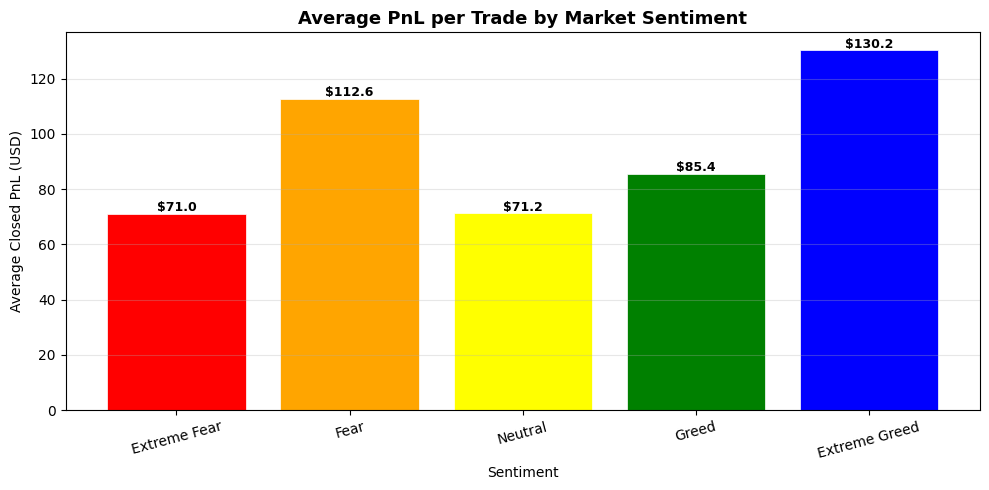

In [31]:
avg_pnl = (
    closed.groupby("classification")["Closed PnL"]
    .mean()
    .reindex(SENT_ORDER)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_pnl.index,
    avg_pnl.values,
    color=[COLORS[c] for c in SENT_ORDER],
    edgecolor="white",
    linewidth=0.5
)

for bar, val in zip(bars, avg_pnl.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"${val:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Average PnL per Trade by Market Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Average Closed PnL (USD)")
plt.xlabel("Sentiment")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_01_avg_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

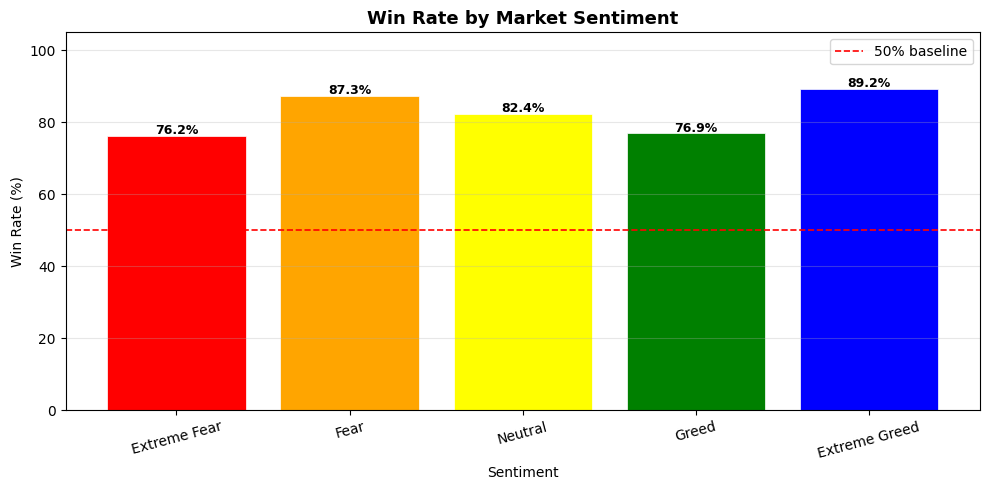

In [32]:
win_rate = (
    closed.groupby("classification")["win"]
    .mean()
    .reindex(SENT_ORDER) * 100
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    win_rate.index,
    win_rate.values,
    color=[COLORS[c] for c in SENT_ORDER],
    edgecolor="white",
    linewidth=0.5
)

plt.axhline(50, color="red", linestyle="--", linewidth=1.2, label="50% baseline")

for bar, val in zip(bars, win_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Win Rate by Market Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Win Rate (%)")
plt.xlabel("Sentiment")
plt.ylim(0, 105)
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_02_win_rate_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

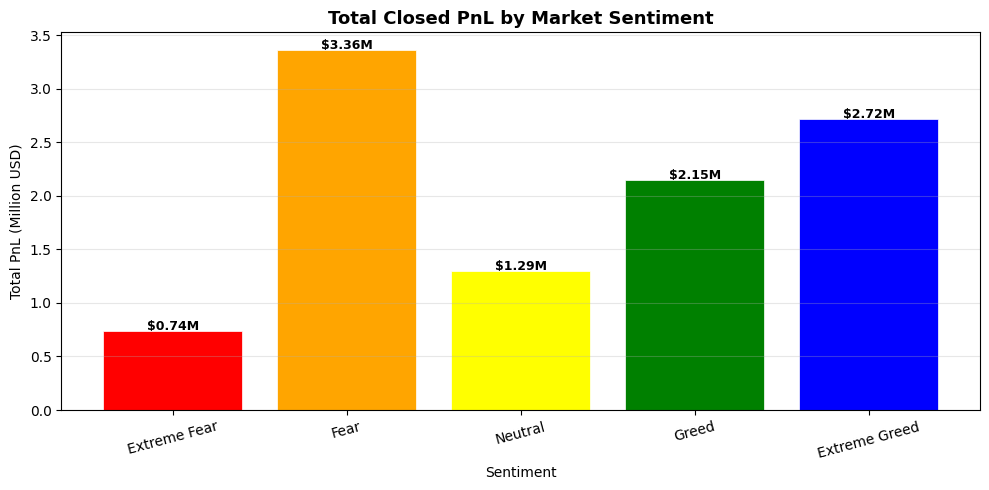

In [33]:
total_pnl = (
    closed.groupby("classification")["Closed PnL"]
    .sum()
    .reindex(SENT_ORDER)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    total_pnl.index,
    total_pnl.values / 1e6,
    color=[COLORS[c] for c in SENT_ORDER],
    edgecolor="white",
    linewidth=0.5
)

for bar, val in zip(bars, total_pnl.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"${val/1e6:.2f}M",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Closed PnL by Market Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Total PnL (Million USD)")
plt.xlabel("Sentiment")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_03_total_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

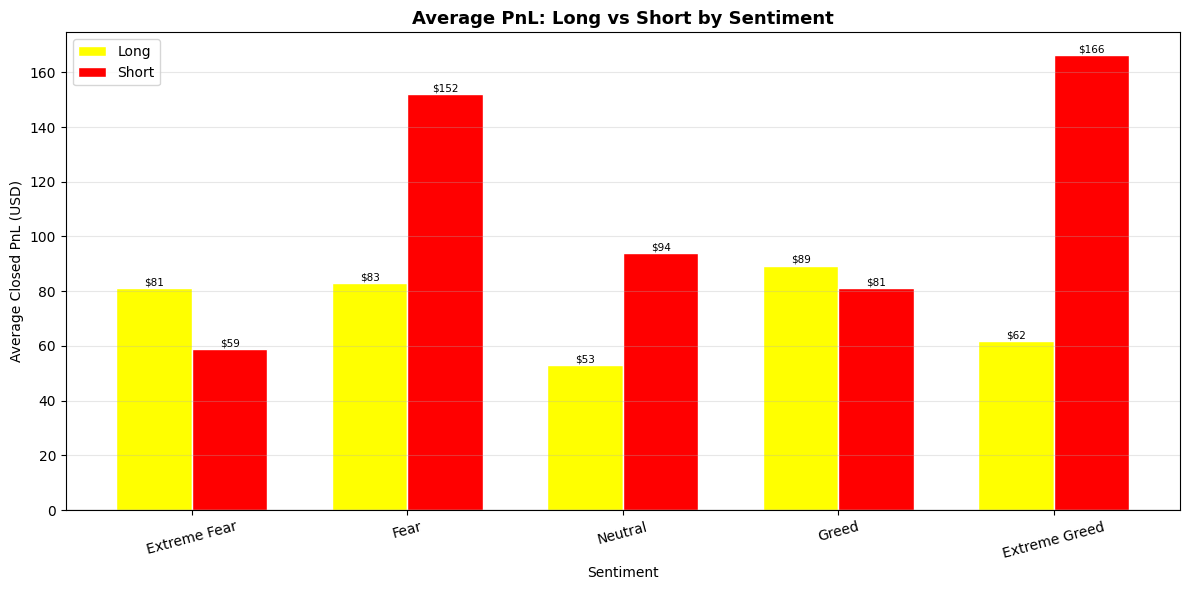

In [34]:
long_pnl  = (
    closed[closed["is_long"]]
    .groupby("classification")["Closed PnL"]
    .mean()
    .reindex(SENT_ORDER)
)

short_pnl = (
    closed[closed["is_short"]]
    .groupby("classification")["Closed PnL"]
    .mean()
    .reindex(SENT_ORDER)
)

x = np.arange(len(SENT_ORDER))
width = 0.35

plt.figure(figsize=(12, 6))

bars_l = plt.bar(x - width/2, long_pnl.values, width, label="Long",  color="yellow", edgecolor="white")
bars_s = plt.bar(x + width/2, short_pnl.values, width, label="Short", color="red", edgecolor="white")

for bar, val in zip(bars_l, long_pnl.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"${val:.0f}", ha="center", fontsize=7.5)

for bar, val in zip(bars_s, short_pnl.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"${val:.0f}", ha="center", fontsize=7.5)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average PnL: Long vs Short by Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Average Closed PnL (USD)")
plt.xlabel("Sentiment")
plt.xticks(x, SENT_ORDER, rotation=15)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_04_long_short_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

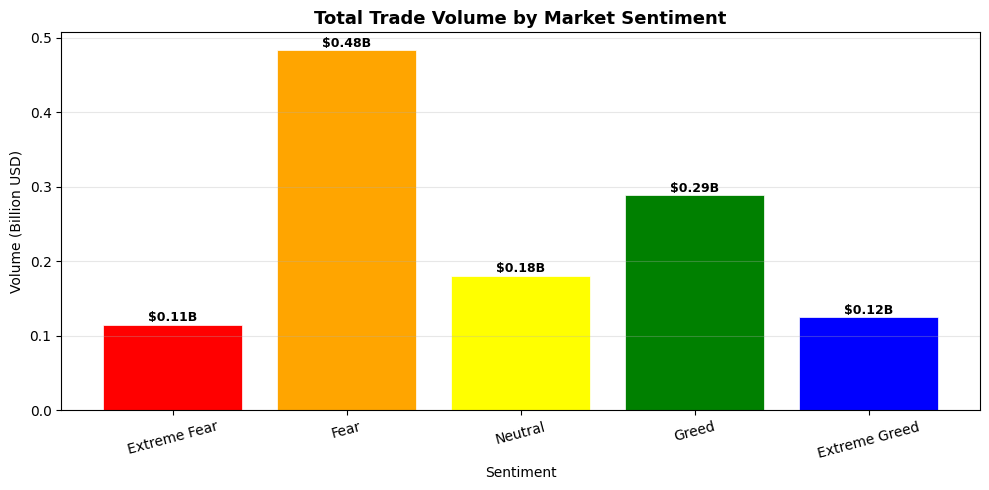

In [35]:
volume = (
    merged.groupby("classification")["Size USD"]
    .sum()
    .reindex(SENT_ORDER)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    volume.index,
    volume.values / 1e9,
    color=[COLORS[c] for c in SENT_ORDER],
    edgecolor="white",
    linewidth=0.5
)

for bar, val in zip(bars, volume.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"${val/1e9:.2f}B",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Trade Volume by Market Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Volume (Billion USD)")
plt.xlabel("Sentiment")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_05_volume_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

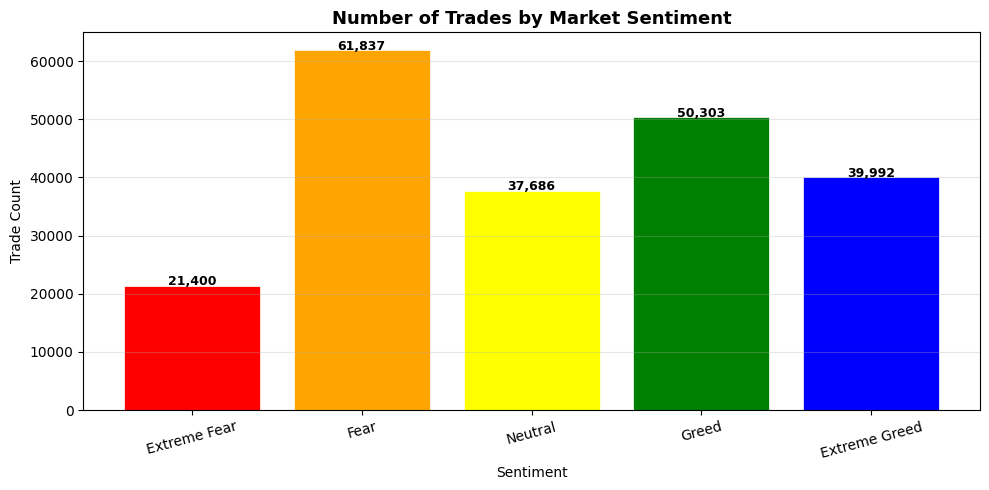

In [36]:
trade_count = (
    merged.groupby("classification")
    .size()
    .reindex(SENT_ORDER)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    trade_count.index,
    trade_count.values,
    color=[COLORS[c] for c in SENT_ORDER],
    edgecolor="white",
    linewidth=0.5
)

for bar, val in zip(bars, trade_count.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Number of Trades by Market Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Trade Count")
plt.xlabel("Sentiment")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_06_trade_count_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

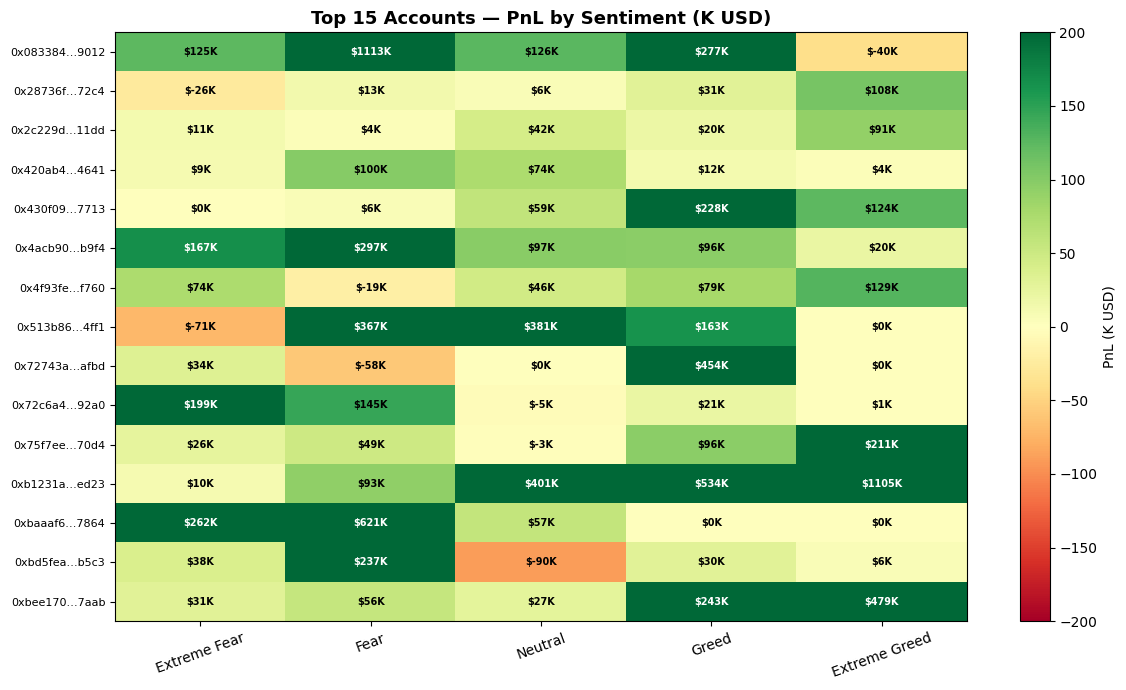

In [37]:
top_accounts = (
    closed.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

acc_sent_pnl = (
    closed[closed["Account"].isin(top_accounts)]
    .groupby(["Account", "classification"])["Closed PnL"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=SENT_ORDER)
)

short_labels = [a[:8] + "…" + a[-4:] for a in acc_sent_pnl.index]

plt.figure(figsize=(12, 7))

im = plt.imshow(
    acc_sent_pnl.values / 1000,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-200,
    vmax=200
)

plt.colorbar(im, label="PnL (K USD)")
plt.xticks(range(5), SENT_ORDER, rotation=20)
plt.yticks(range(len(acc_sent_pnl)), short_labels, fontsize=8)

for i in range(len(acc_sent_pnl)):
    for j in range(5):
        val = acc_sent_pnl.values[i, j]
        plt.text(
            j, i,
            f"${val/1000:.0f}K",
            ha="center", va="center",
            color="black" if abs(val) < 150000 else "white",
            fontsize=7, fontweight="bold"
        )

plt.title("Top 15 Accounts — PnL by Sentiment (K USD)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(output_path + "/st_07_top_accounts_sentiment_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

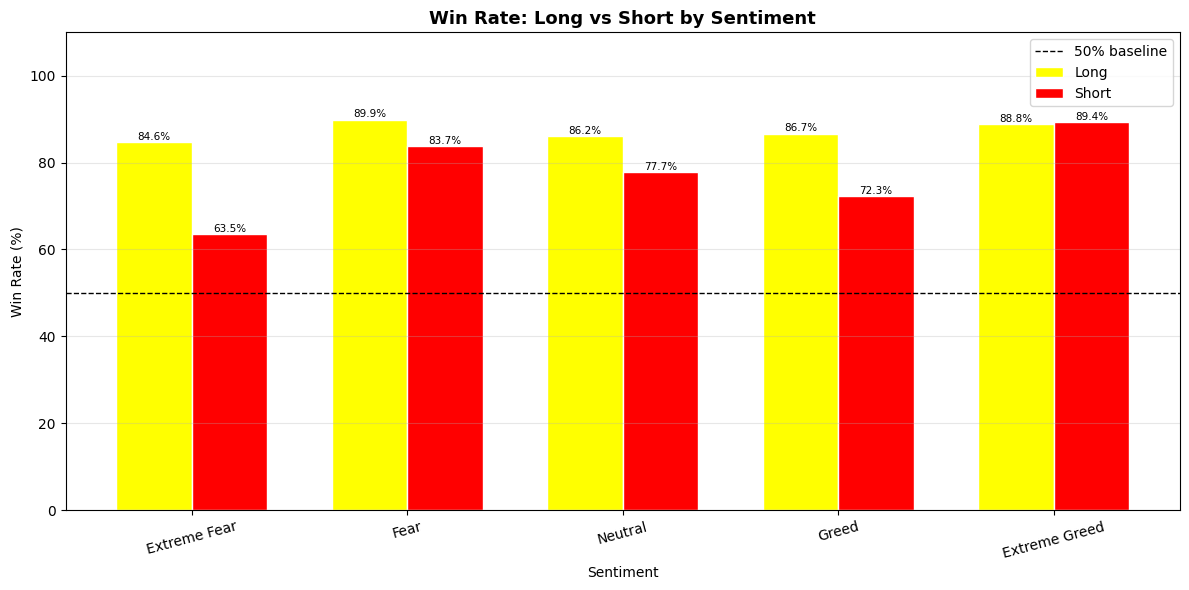

In [38]:
long_wr  = (
    closed[closed["is_long"]]
    .groupby("classification")["win"]
    .mean()
    .reindex(SENT_ORDER) * 100
)

short_wr = (
    closed[closed["is_short"]]
    .groupby("classification")["win"]
    .mean()
    .reindex(SENT_ORDER) * 100
)

x = np.arange(len(SENT_ORDER))
width = 0.35

plt.figure(figsize=(12, 6))

bars_l = plt.bar(x - width/2, long_wr.values,  width, label="Long",  color="yellow", edgecolor="white")
bars_s = plt.bar(x + width/2, short_wr.values, width, label="Short", color="red", edgecolor="white")

for bar, val in zip(bars_l, long_wr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=7.5)

for bar, val in zip(bars_s, short_wr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=7.5)

plt.axhline(50, color="black", linestyle="--", linewidth=1, label="50% baseline")
plt.title("Win Rate: Long vs Short by Sentiment", fontsize=13, fontweight="bold")
plt.ylabel("Win Rate (%)")
plt.xlabel("Sentiment")
plt.ylim(0, 110)
plt.xticks(x, SENT_ORDER, rotation=15)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_path + "/st_08_winrate_long_short_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

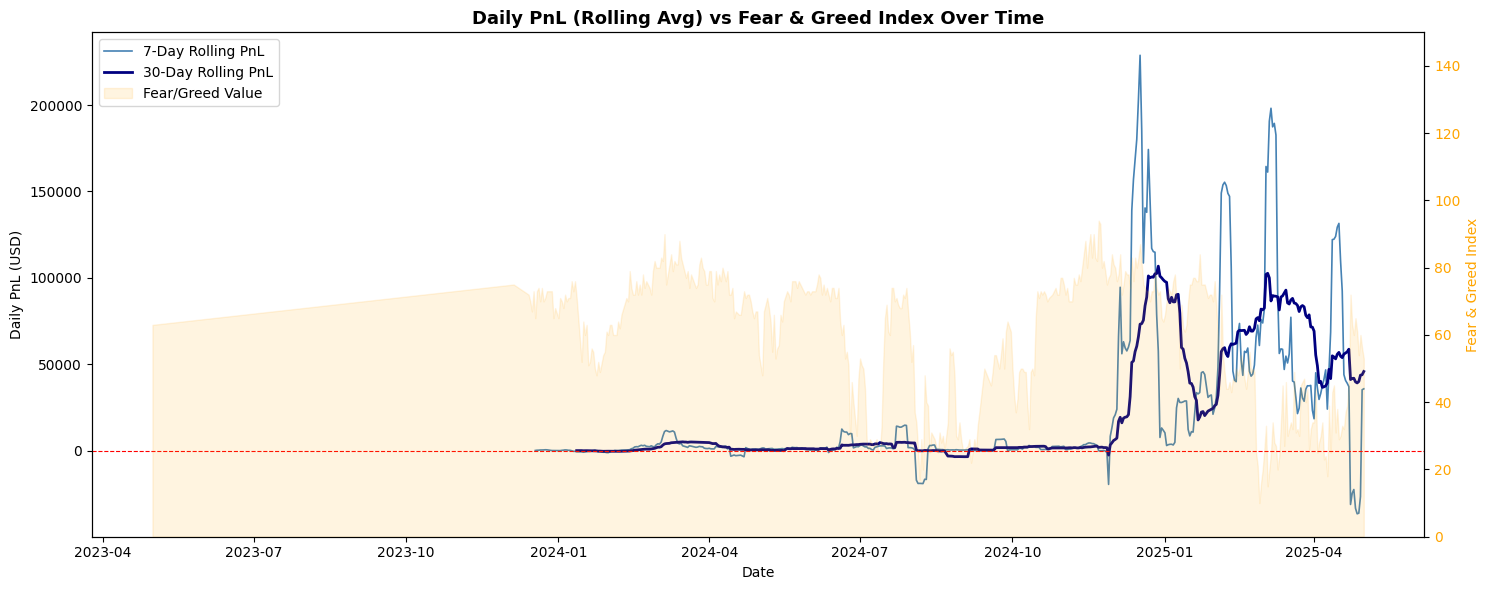

In [39]:
daily = (
    merged.groupby(["date_only", "classification"])
    .agg(daily_pnl=("Closed PnL", "sum"), fg_value=("value", "mean"))
    .reset_index()
)

daily["date_only"] = pd.to_datetime(daily["date_only"])
daily = daily.sort_values("date_only")

agg_daily = (
    merged.groupby("date_only")
    .agg(daily_pnl=("Closed PnL", "sum"), fg_value=("value", "mean"))
    .reset_index()
)

agg_daily["date_only"] = pd.to_datetime(agg_daily["date_only"])
agg_daily = agg_daily.sort_values("date_only")
agg_daily["rolling_7"] = agg_daily["daily_pnl"].rolling(7).mean()
agg_daily["rolling_30"] = agg_daily["daily_pnl"].rolling(30).mean()

fig, ax1 = plt.subplots(figsize=(15, 6))

ax2 = ax1.twinx()

ax2.fill_between(
    agg_daily["date_only"],
    agg_daily["fg_value"],
    alpha=0.12,
    color="orange",
    label="Fear/Greed Value"
)

ax2.set_ylabel("Fear & Greed Index", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.set_ylim(0, 150)

ax1.plot(
    agg_daily["date_only"],
    agg_daily["rolling_7"],
    color="steelblue",
    linewidth=1.2,
    label="7-Day Rolling PnL"
)

ax1.plot(
    agg_daily["date_only"],
    agg_daily["rolling_30"],
    color="navy",
    linewidth=2,
    label="30-Day Rolling PnL"
)

ax1.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax1.set_ylabel("Daily PnL (USD)")
ax1.set_xlabel("Date")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Daily PnL (Rolling Avg) vs Fear & Greed Index Over Time",
          fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(output_path + "/st_09_daily_pnl_vs_fg_index.png", dpi=300, bbox_inches="tight")
plt.show()

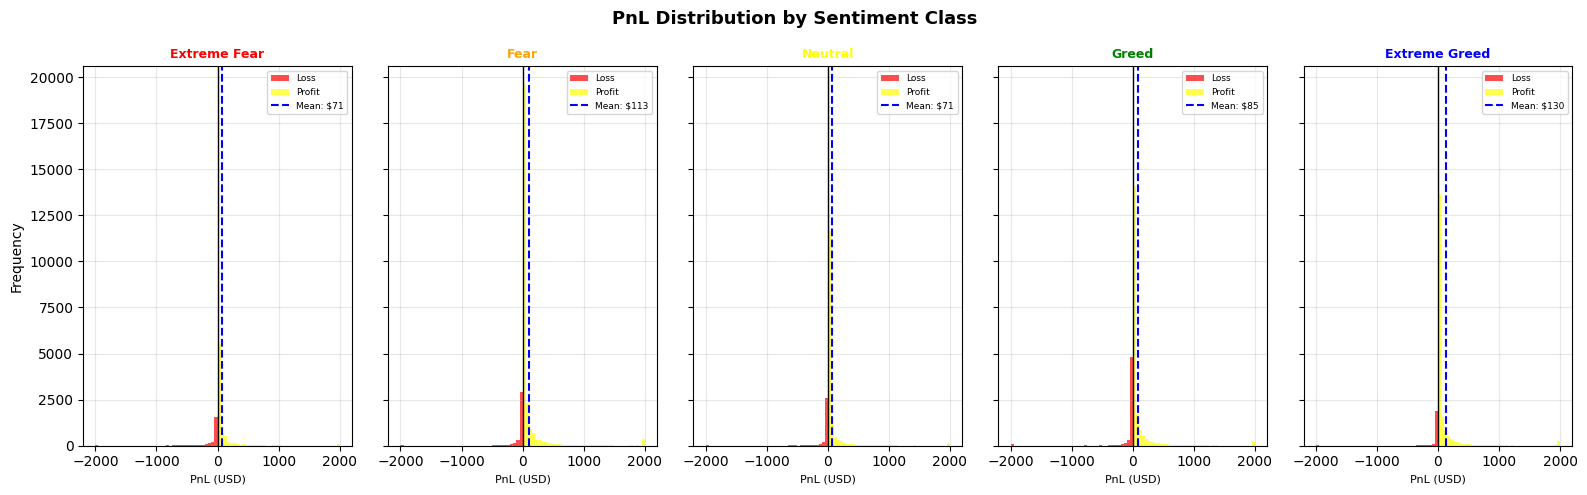

In [40]:
ef_pnl = closed[closed["classification"] == "Extreme Fear"]["Closed PnL"]
eg_pnl = closed[closed["classification"] == "Extreme Greed"]["Closed PnL"]
fe_pnl = closed[closed["classification"] == "Fear"]["Closed PnL"]
gr_pnl = closed[closed["classification"] == "Greed"]["Closed PnL"]
ne_pnl = closed[closed["classification"] == "Neutral"]["Closed PnL"]

fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)

for ax, pnl, cls in zip(
    axes,
    [ef_pnl, fe_pnl, ne_pnl, gr_pnl, eg_pnl],
    SENT_ORDER
):
    clipped = pnl.clip(-2000, 2000)
    ax.hist(clipped[clipped < 0], bins=40, color="red", alpha=0.7, label="Loss")
    ax.hist(clipped[clipped > 0], bins=40, color="yellow", alpha=0.7, label="Profit")
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(pnl.mean(), color="blue", linewidth=1.5, linestyle="--",
               label=f"Mean: ${pnl.mean():.0f}")
    ax.set_title(cls, fontsize=9, fontweight="bold", color=COLORS[cls])
    ax.set_xlabel("PnL (USD)", fontsize=8)
    ax.legend(fontsize=6.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Frequency")
fig.suptitle("PnL Distribution by Sentiment Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(output_path + "/st_10_pnl_distribution_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
print("=" * 60)
print("SENTIMENT vs TRADER PERFORMANCE — SUMMARY")
print("=" * 60)

summary = closed.groupby("classification").agg(
    trades = ("Closed PnL", "count"),
    avg_pnl = ("Closed PnL", "mean"),
    total_pnl = ("Closed PnL", "sum"),
    win_rate_pct = ("win", lambda x: round(x.mean() * 100, 2)),
    median_pnl = ("Closed PnL", "median"),
).reindex(SENT_ORDER)

print(summary.to_string())

print("\nAll sentiment-trader visualizations saved successfully.")

SENTIMENT vs TRADER PERFORMANCE — SUMMARY
                trades     avg_pnl     total_pnl  win_rate_pct  median_pnl
classification                                                            
Extreme Fear     10406   71.027316  7.391102e+05         76.22    6.388050
Fear             29808  112.625988  3.357155e+06         87.29    6.350483
Neutral          18159   71.199993  1.292921e+06         82.39    4.583458
Greed            25176   85.403927  2.150129e+06         76.89    4.927600
Extreme Greed    20853  130.205309  2.715171e+06         89.17    8.530740

All sentiment-trader visualizations saved successfully.
